# Pipeline Moises — scriptCS_testing.m em Python

Carrega vídeo, remove DC, aplica Hilbert (X0, X90), PCA dual, Complexity Pursuit (BSS) e extrai formas modais e coordenadas modais. Funções em `src/moises`.

## Imports

In [1]:
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

# Recarrega moises via sys.modules (evita AttributeError em moises.data)
def reload_moises():
    leaf = [
        "moises.data.load",
        "moises.augmentation.hilbert",
        "moises.decomposition.pca_dual",
        "moises.cp.cp_alg",
        "moises.modal.solve",
    ]
    for name in leaf:
        if name in sys.modules:
            importlib.reload(sys.modules[name])
        else:
            __import__(name)
    for name in ["moises.data", "moises.augmentation", "moises.decomposition", "moises.cp", "moises.modal"]:
        if name in sys.modules:
            importlib.reload(sys.modules[name])
    if "moises" in sys.modules:
        importlib.reload(sys.modules["moises"])

reload_moises()

from moises import (
    load_video_dataset,
    hilbert_augment,
    pca_dual,
    cp_alg,
    solve_modal,
)

## Parâmetros e carregamento do vídeo

In [2]:
video_path = "videos/20260207/60fps/VID_20260207_082108999.mp4"  # ajuste o caminho se necessário
max_frames = 400  # None = carregar todo o vídeo

dataset, fps, (n_rows, n_cols), mean, frames = load_video_dataset(video_path, max_frames=max_frames)
n_frames, n_pixels = dataset.shape
dt = 1.0 / fps
t = np.arange(n_frames) / fps
freq = np.arange(n_frames) * fps / n_frames


print(f"Frames: {n_frames}, shape: {n_rows}x{n_cols}, FPS: {fps}")
print(f"Dataset: {dataset.shape}, mean removido (DC).")



Frames: 400, shape: 960x540, FPS: 60
Dataset: (400, 518400), mean removido (DC).


## Aumento de dados (Hilbert)

In [3]:
X0, X90 = hilbert_augment(dataset)
print("X0 (real):", X0.shape, "— X90 (imag):", X90.shape)

print(X0)

X0 (real): (400, 518400) — X90 (imag): (400, 518400)
[[ 0.10499573  3.0625      2.737503   ...  0.8200073   1.3074951
  -1.1224976 ]
 [ 0.10499573  3.0625      2.737503   ...  0.8200073   1.3074951
  -1.1224976 ]
 [-0.8950043  -0.9375     -1.262497   ... -1.1799927   1.3074951
  -1.1224976 ]
 ...
 [-1.8950043  -0.9375     -1.262497   ... -1.1799927   1.3074951
  -0.12249756]
 [-1.8950043   0.0625     -2.262497   ... -0.17999268  1.3074951
   0.87750244]
 [ 1.1049957   1.0625      0.73750305 ... -0.17999268 -0.6925049
  -0.12249756]]


## PCA dual (real + imaginário) e ordenação

In [ ]:
H, W, V = pca_dual(X0, X90)
print("H (scores):", H.shape, "— W (loadings):", W.shape)

PCA over X0
PCA over X90
End of Dim. Red.


## Blind Source Separation (Complexity Pursuit)

In [6]:
num_pc = 16
ys, W_mix = cp_alg(H[:, :num_pc])
print("Fontes (ys):", ys.shape, "— W_mix:", W_mix.shape)

Fontes (ys): (400, 16) — W_mix: (16, 16)


## Formas modais e coordenadas modais

In [7]:
# Índices das fontes com comportamento monotônico (equivalente ao srcs do MATLAB)
srcs = [0, 1, 8, 9, 13, 14]  # 1-based no MATLAB -> 0-based aqui
modal_coord, mode_shapes = solve_modal(ys, W_mix, W, srcs, num_pc=num_pc)
print("modal_coord (espacial):", modal_coord.shape, "— mode_shapes (temporal):", mode_shapes.shape)

modal_coord (espacial): (400, 6) — mode_shapes (temporal): (82944, 6)


## Visualização: fontes (sinais no tempo, PSD e fase)

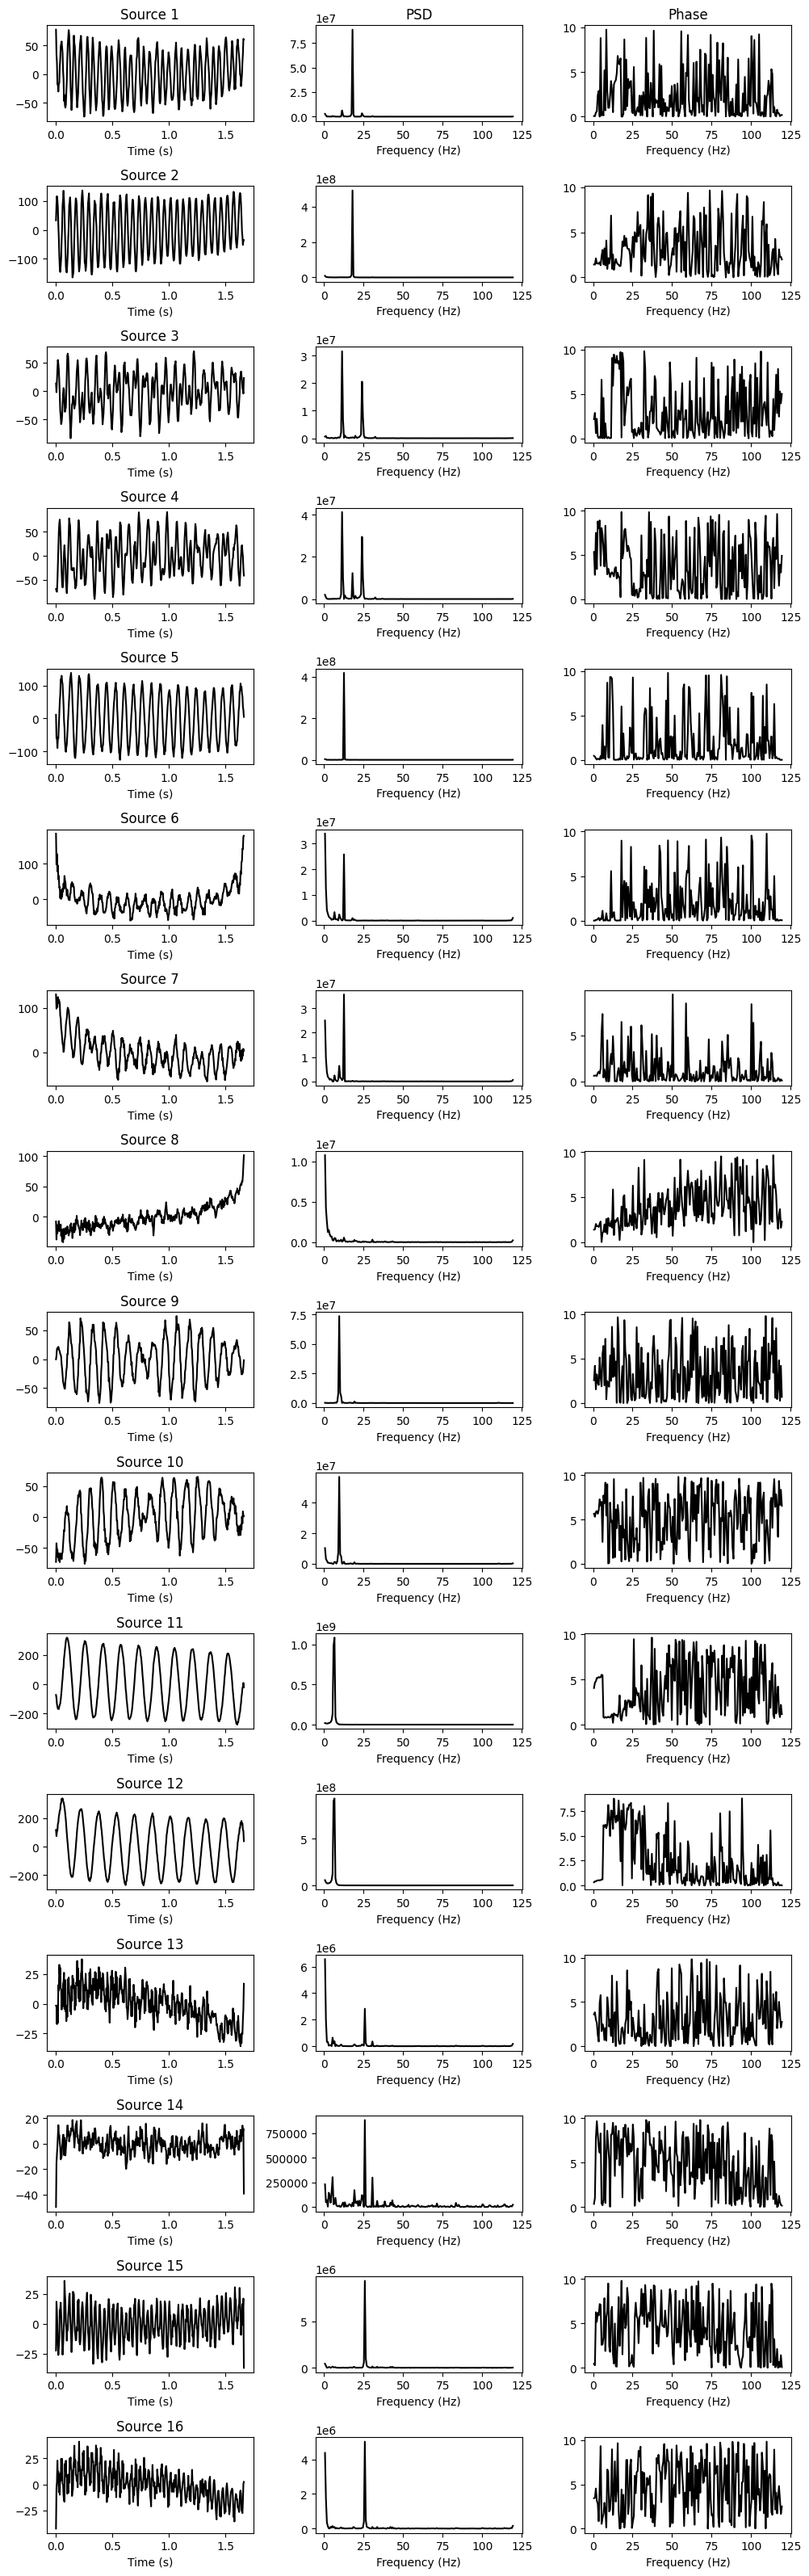

In [8]:
def plot_sources(t, freq, unmixed, n_show=None, fs=1.0):
    nFrames = len(t)
    half = round(nFrames / 2)
    n = n_show or unmixed.shape[1]

    fig, axs = plt.subplots(n, 3, figsize=(10, 2 * n))

    for i in range(n):
        axs[i, 0].plot(t, unmixed[:, i], "k", lw=1.5)
        axs[i, 0].set_title(f"Source {i+1}")
        axs[i, 0].set_xlabel("Time (s)")

        fft_mag = np.abs(np.fft.fft(unmixed[:, i]))**2
        axs[i, 1].plot(freq[1:half], fft_mag[1:half], "k", lw=1.5)
        axs[i, 1].set_title("PSD" if i == 0 else "")
        axs[i, 1].set_xlabel("Frequency (Hz)")

        fft_phase = np.angle(np.fft.fft(unmixed[:, i]))**2
        axs[i, 2].plot(freq[1:half], fft_phase[1:half], "k", lw=1.5)
        axs[i, 2].set_title("Phase" if i == 0 else "")
        axs[i, 2].set_xlabel("Frequency (Hz)")

    plt.tight_layout()
    return fig

unmixed = -np.fliplr(ys)  # convenção do script MATLAB
plot_sources(t, freq, unmixed);
plt.show()

## Visualização: formas modais (espacial)

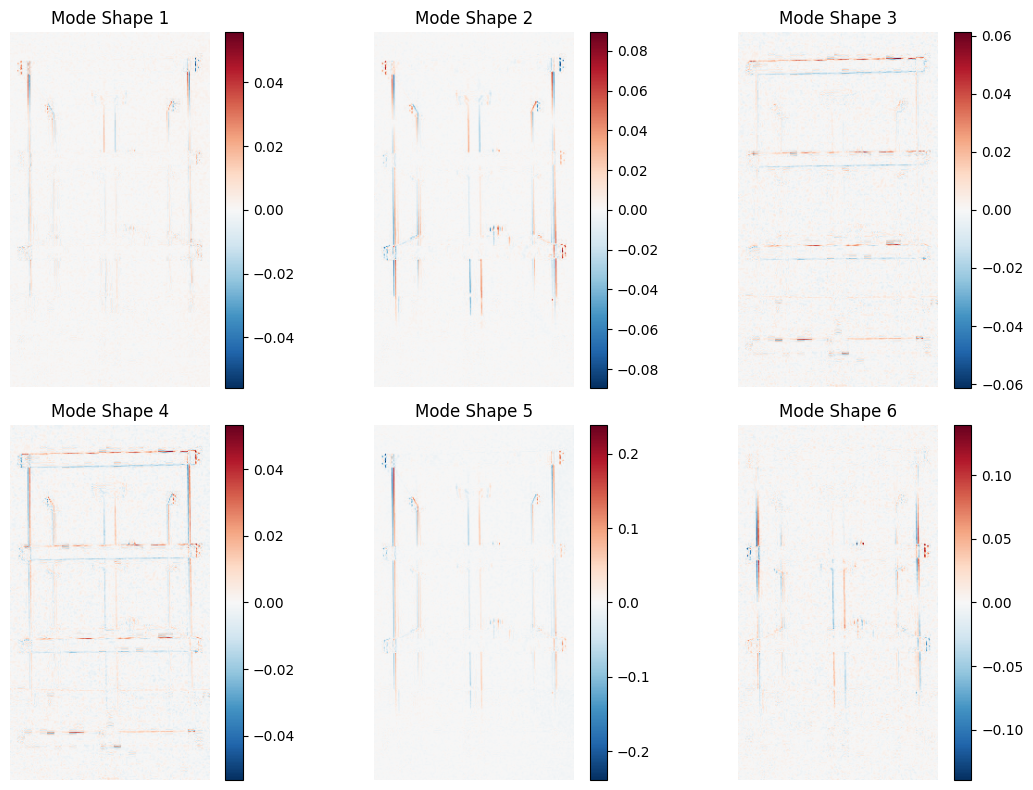

In [9]:
n_srcs = len(srcs)
fig, axs = plt.subplots(2, n_srcs // 2, figsize=(4 * (n_srcs // 2), 8))
axs = axs.flatten()
for i in range(n_srcs):
    S = mode_shapes[:, i].reshape(n_rows, n_cols)

    vmax = np.abs(S).max()
    vmin = -vmax

    im = axs[i].imshow(S, cmap='RdBu_r', vmin=vmin, vmax=vmax)  # diverging colormap

    axs[i].set_title(f"Mode Shape {i+1}")
    axs[i].axis("off")
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Visualização: coordenadas modais (tempo, PSD, fase)

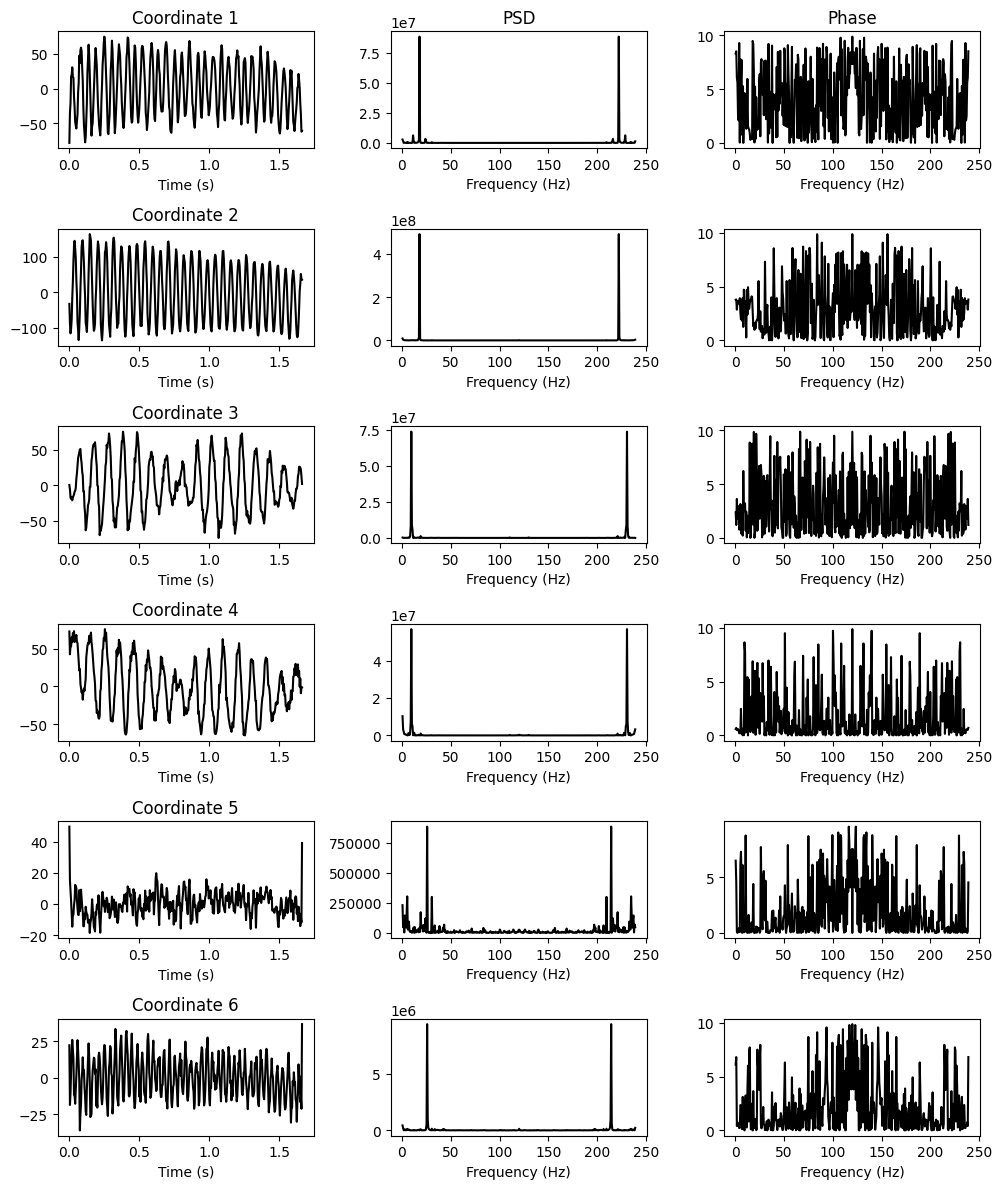

In [10]:
half = len(freq) - 1
fig, axs = plt.subplots(n_srcs, 3, figsize=(10, 2 * n_srcs))
for i in range(n_srcs):
    axs[i, 0].plot(t, modal_coord[:, i], "k", lw=1.5)
    axs[i, 0].set_title(f"Coordinate {i+1}")
    axs[i, 0].set_xlabel("Time (s)")
    fft_mag = np.abs(np.fft.fft(   modal_coord[:, i])) ** 2
    axs[i, 1].plot(freq[1:half], fft_mag[1:half], "k", lw=1.5)
    axs[i, 1].set_title("PSD" if i == 0 else "")
    axs[i, 1].set_xlabel("Frequency (Hz)")
    fft_phase = np.angle(np.fft.fft(modal_coord[:, i])) ** 2
    axs[i, 2].plot(freq[1:half], fft_phase[1:half], "k", lw=1.5)
    axs[i, 2].set_title("Phase" if i == 0 else "")
    axs[i, 2].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

## Reconstrução do vídeo e taxa de compressão

Norm^2 (original - reconstruído): 1.1581997877298877e-20


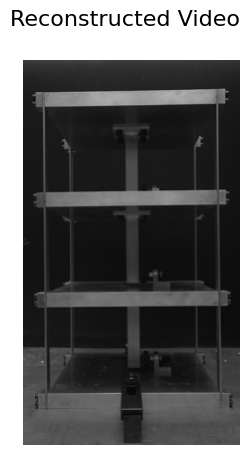

Compressão (modos vs vídeo): 0.8794


In [13]:
# Reconstrução: (n_frames, n_pixels) = mode_shapes @ modal_coord.T
reconstructed = (mode_shapes @ modal_coord.T).T  # (n_frames, n_pixels)
bckgd = mean.reshape(n_rows, n_cols)

error = np.zeros((n_rows, n_cols))
for j in range(n_frames):
    F0 = reconstructed[j, :].reshape(n_rows, n_cols) + bckgd
    error += frames[:, :, j].astype(float) - F0

norm_sq = np.sum(error.ravel()) ** 2
print("Norm^2 (original - reconstruído):", norm_sq)

# Taxa de compressão (apenas formas modais + coordenadas vs vídeo inteiro)
bytes_modes = modal_coord.nbytes + mode_shapes.nbytes
bytes_frames = frames.nbytes
# Render the reconstructed video
import matplotlib.animation as animation

fig_recon, ax_recon = plt.subplots(figsize=(5, 5))
im = ax_recon.imshow(np.zeros((n_rows, n_cols)), cmap='gray', vmin=0, vmax=255)
ax_recon.axis('off')
fig_recon.suptitle("Reconstructed Video", fontsize=16)

def update(frame_idx):
    frame_data = reconstructed[frame_idx, :].reshape(n_rows, n_cols) + bckgd
    im.set_array(np.clip(frame_data, 0, 255))
    return [im]

ani = animation.FuncAnimation(
    fig_recon, update, frames=n_frames, interval=1000/fps, blit=True, repeat=False
)
plt.show()

compression_rate = 1 - (bytes_modes / bytes_frames)
print(f"Compressão (modos vs vídeo): {compression_rate:.4f}")